In [23]:
#inport Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
#1.LOAD AND PREPROCESS DATA
def load_data(train_dir, test_dir, batch_size=32):

    # Transformations: Resize + Convert to tensor + Normalize
    transform = transforms.Compose([
        transforms.Resize((64, 64)),  # keep size fixed
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5),   # normalize RGB channels
                             (0.5, 0.5, 0.5))
    ])
    # Load dataset
    train_data = datasets.ImageFolder(train_dir, transform=transform)
    test_data = datasets.ImageFolder(test_dir, transform=transform)

    # Create data loaders
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

    # Number of classes (important for output layer)
    num_classes = len(train_data.classes)

    return train_loader, test_loader, num_classes

In [25]:
#2.DEFINE CNN MODEL
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        # CL1 → 4 feature maps
        self.conv1 = nn.Conv2d(
            in_channels=3, out_channels=4,
            kernel_size=3, stride=1, padding=1
        )

        # PL1 → Mean Pooling
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        # CL2 → 8 feature maps
        self.conv2 = nn.Conv2d(
            in_channels=4, out_channels=8,
            kernel_size=3, stride=1, padding=1
        )

        # PL2 → Mean Pooling
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        # Fully Connected Layer
        # NOTE: Input size = 64x64 → after pooling → 16x16
        self.fc = nn.Linear(8 * 16 * 16, num_classes)

    def forward(self, x):

        # CL1 + ReLU
        x = torch.relu(self.conv1(x))

        # PL1
        x = self.pool1(x)

        # CL2 + ReLU
        x = torch.relu(self.conv2(x))

        # PL2
        x = self.pool2(x)

        # Flatten (convert 2D → 1D)
        x = x.view(x.size(0), -1)

        # Fully connected layer
        x = self.fc(x)

        return x

In [26]:
#3.TRAINING FUNCTION
def train_model(model, train_loader, criterion, optimizer, device, epochs=10):

    model.train()

    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Forward
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # Accuracy calculation
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        accuracy = 100 * correct / total

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}, Accuracy: {accuracy:.2f}%")

In [27]:
# Confusion Matrix Function
def plot_confusion_matrix(model, test_loader, device):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

In [28]:
#4.Test Function
def test_model(model, test_loader, device):

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Accuracy: {100 * correct / total:.2f}%")

Epoch [1/10], Loss: 139.1601, Accuracy: 46.80%
Epoch [2/10], Loss: 114.8134, Accuracy: 59.69%
Epoch [3/10], Loss: 109.1780, Accuracy: 62.46%
Epoch [4/10], Loss: 105.9930, Accuracy: 62.83%
Epoch [5/10], Loss: 104.0657, Accuracy: 63.97%
Epoch [6/10], Loss: 100.0726, Accuracy: 65.91%
Epoch [7/10], Loss: 98.5974, Accuracy: 66.23%
Epoch [8/10], Loss: 95.3279, Accuracy: 67.94%
Epoch [9/10], Loss: 94.8554, Accuracy: 67.77%
Epoch [10/10], Loss: 92.8372, Accuracy: 68.51%
Accuracy: 61.43%


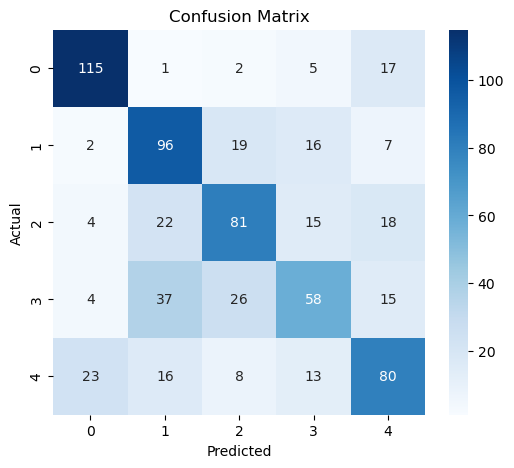

In [29]:
#5.Main Function
def main():

    train_dir =r"C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 2\DataSets\Image dataset for classification\train"
    test_dir =  r"C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 2\DataSets\Image dataset for classification\test"

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader, test_loader, num_classes = load_data(train_dir, test_dir)

    model = CNN(num_classes).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_model(model, train_loader, criterion, optimizer, device, epochs=10)
    test_model(model, test_loader, device)

    # Confusion Matrix
    plot_confusion_matrix(model, test_loader, device)


if __name__ == "__main__":
    main()